 # Hands-On Task: Diamond Price Prediction Pipeline



 Proyek ini membangun *end-to-end machine learning pipeline* menggunakan Scikit-learn untuk memprediksi harga berlian, mencakup EDA, pembersihan data, *multiple linear regression*, *polynomial regression*, hingga bonus advanced pipeline.

 ## Stage 1: Data Preparation and EDA

 ### 1.1 Data Loading & Dimensional Anomaly Handling



 Kita memuat dataset `diamonds` dari Seaborn dan membuang baris dengan dimensi tidak logis ($x \le 0, y \le 0, z \le 0$) serta *extreme measurement outliers* ($y > 30$ mm atau $z > 30$ mm).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = sns.load_dataset('diamonds')

# Filtering zero values and extreme measurement errors
df_clean = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0) & (df['y'] <= 30) & (df['z'] <= 30)].copy()

print(f"Original shape : {df.shape}")
print(f"Cleaned shape  : {df_clean.shape}")
print(f"Removed rows   : {len(df) - len(df_clean)}")


Original shape : (53940, 10)
Cleaned shape  : (53917, 10)
Removed rows   : 23


 ### 1.2 Correlation Analysis



 Analisis korelasi linier antara semua fitur numerik terhadap harga (`price`).

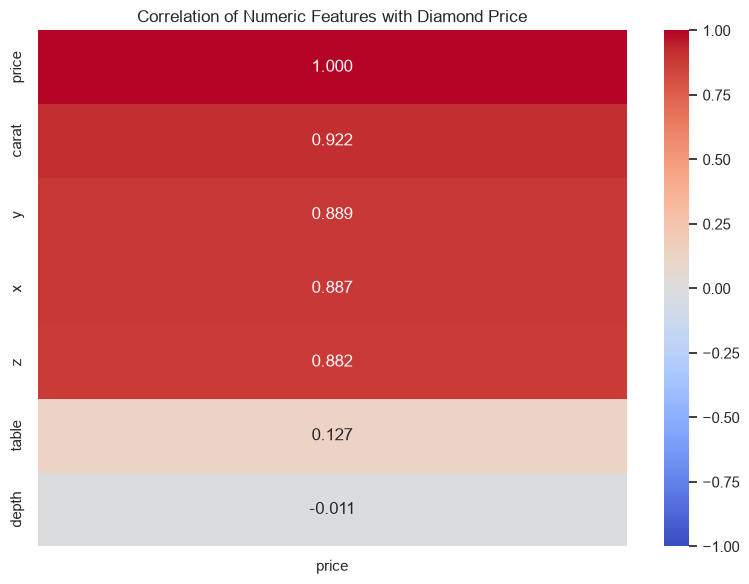

Highest correlated feature : carat (0.922)
Lowest correlated feature  : depth (-0.011)


In [2]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')
plt.title('Correlation of Numeric Features with Diamond Price', fontsize=12)
plt.tight_layout()
plt.show()

highest_corr = corr_matrix['price'].drop('price').idxmax()
lowest_corr = corr_matrix['price'].abs().drop('price').idxmin()

print(f"Highest correlated feature : {highest_corr} ({corr_matrix.loc[highest_corr, 'price']:.3f})")
print(f"Lowest correlated feature  : {lowest_corr} ({corr_matrix.loc[lowest_corr, 'price']:.3f})")


 ### 1.3 Target Distribution Analysis



 Distribusi `price` bersifat *right-skewed*. Transformasi logaritma menormalisasi distribusi dan menstabilkan varians.

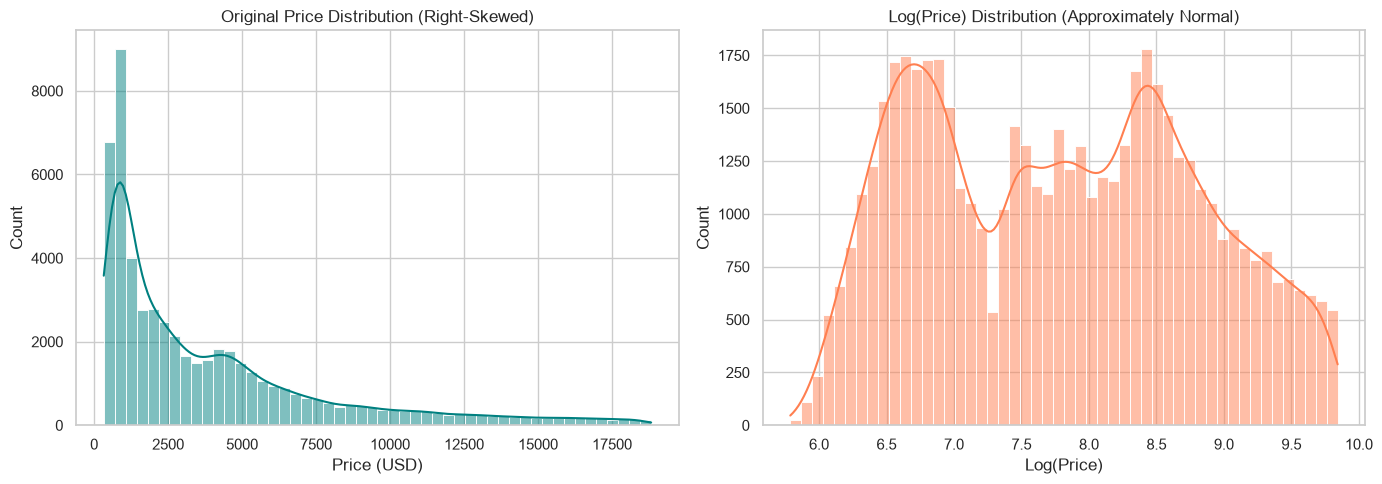

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean['price'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Original Price Distribution (Right-Skewed)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log(df_clean['price']), bins=50, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Log(Price) Distribution (Approximately Normal)')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.show()


 ### 1.4 Carat vs Price by Cut Quality



 Visualisasi hubungan non-linear antara berat (`carat`) dan harga (`price`) berdasarkan kualitas potongan (`cut`).

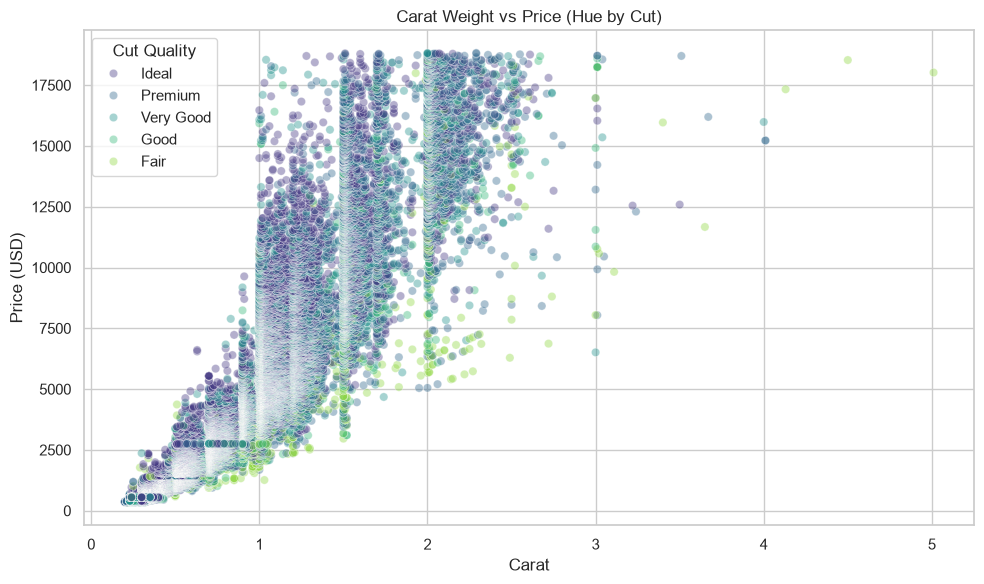

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='carat', y='price', hue='cut', alpha=0.4, palette='viridis')
plt.title('Carat Weight vs Price (Hue by Cut)', fontsize=12)
plt.xlabel('Carat')
plt.ylabel('Price (USD)')
plt.legend(title='Cut Quality')
plt.tight_layout()
plt.show()


 ## Stage 2: Simple and Multiple Linear Regression

 ### 2.1 Model Pipeline & Evaluation (Numeric Features Only)



 Menggunakan fitur numerik asli (`carat`, `depth`, `table`, `x`, `y`, `z`) dengan `Pipeline` berisi `StandardScaler` dan `LinearRegression`. Split data 80/20 (`random_state=42`).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_num = df_clean[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42)

mlr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

mlr_pipeline.fit(X_train, y_train)

y_train_pred = mlr_pipeline.predict(X_train)
y_test_pred = mlr_pipeline.predict(X_test)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2 Score'],
    'Train Set': [
        mean_absolute_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        r2_score(y_train, y_train_pred)
    ],
    'Test Set': [
        mean_absolute_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        r2_score(y_test, y_test_pred)
    ]
})

print("=== Stage 2 MLR Performance Metrics ===")
print(metrics_df.to_string(index=False))


=== Stage 2 MLR Performance Metrics ===
  Metric   Train Set    Test Set
     MAE  890.245604  873.505756
    RMSE 1493.770073 1453.639128
R2 Score    0.859942    0.865930


 ### 2.2 Residual Diagnostics



 Plot residual vs fitted values dan histogram residual untuk mengevaluasi homoskedastisitas dan asumsi normalitas.

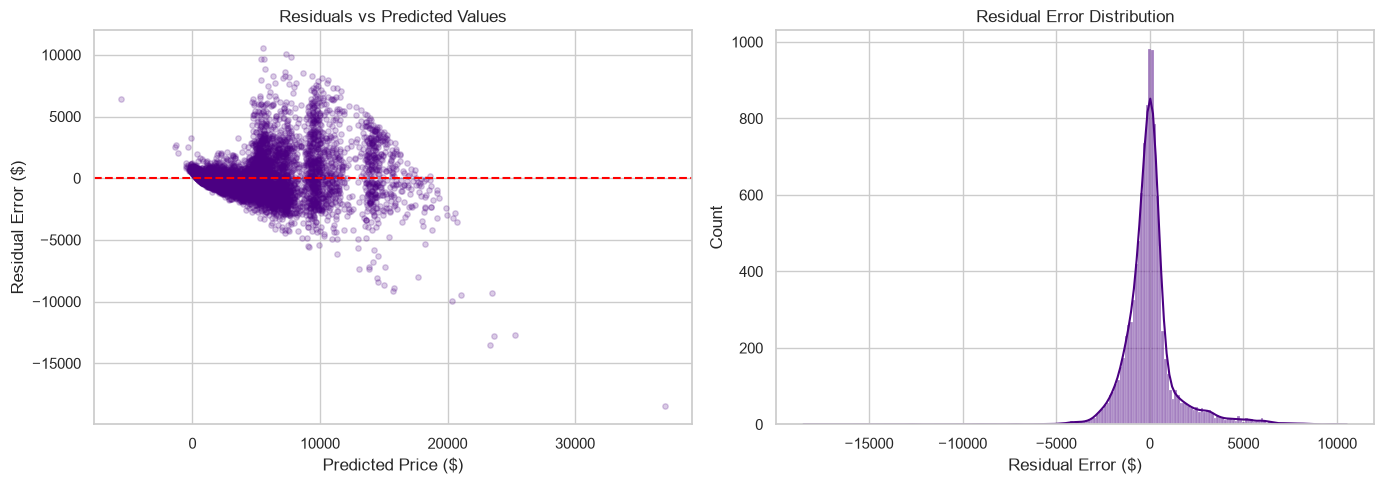

In [6]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_pred, residuals, alpha=0.2, color='indigo', s=15)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual Error ($)')

sns.histplot(residuals, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('Residual Error Distribution')
axes[1].set_xlabel('Residual Error ($)')

plt.tight_layout()
plt.show()


 ### 2.3 Feature Coefficients & Multicollinearity Inspection



 Memeriksa koefisien terstandarisasi untuk menentukan fitur yang paling berpengaruh.

In [7]:
coef_df = pd.DataFrame({
    'Feature': X_num.columns,
    'Standardized Coef': mlr_pipeline.named_steps['regressor'].coef_
}).sort_values(by='Standardized Coef', ascending=False)

print("=== Standardized Feature Coefficients ===")
print(coef_df.to_string(index=False))


=== Standardized Feature Coefficients ===
Feature  Standardized Coef
  carat        5172.769431
      y        3480.809954
  depth         -94.237229
  table        -204.787105
      z       -1459.957364
      x       -3509.230680


 **Analisis Koefisien:**

 Fitur `carat` memiliki pengaruh positif terbesar terhadap harga. Fitur spasial `x`, `y`, dan `z` menunjukkan koefisien bernilai negatif atau kontra-intuitif akibat multikolinearitas yang sangat tinggi di antara ketiganya.

 ## Stage 3: Polynomial Regression Analysis

 ### 3.1 Polynomial Features on Single Predictor (Carat)



 Melatih model regresi polinomial derajat 1, 2, 3, dan 5 hanya menggunakan fitur `carat`.

In [8]:
from sklearn.preprocessing import PolynomialFeatures

X_carat_train = X_train[['carat']]
X_carat_test = X_test[['carat']]

degrees = [1, 2, 3, 5]
poly_results = []
poly_models = {}

for deg in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('reg', LinearRegression())
    ])
    pipe.fit(X_carat_train, y_train)
    poly_models[deg] = pipe
    
    tr_pred = pipe.predict(X_carat_train)
    te_pred = pipe.predict(X_carat_test)
    
    poly_results.append({
        'Degree': f'Degree {deg}',
        'Train R2': r2_score(y_train, tr_pred),
        'Test R2': r2_score(y_test, te_pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, te_pred))
    })

poly_summary = pd.DataFrame(poly_results)
print("=== Polynomial Models Performance ===")
print(poly_summary.to_string(index=False))


=== Polynomial Models Performance ===
  Degree  Train R2  Test R2   Test RMSE
Degree 1  0.848544 0.852448 1524.975544
Degree 2  0.849962 0.854957 1511.956674
Degree 3  0.864262 0.868168 1441.451439
Degree 5  0.869322 0.872641 1416.789628


 ### 3.2 Visualizing Polynomial Fits (500 Sampled Points)



 Menampilkan kurva polynomial di atas *scatter plot* 500 sampel data acak.

c:\Users\LENOVO\gdgoc-ai-handson\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\gdgoc-ai-handson\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\gdgoc-ai-handson\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\LENOVO\gdgoc-ai-handson\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


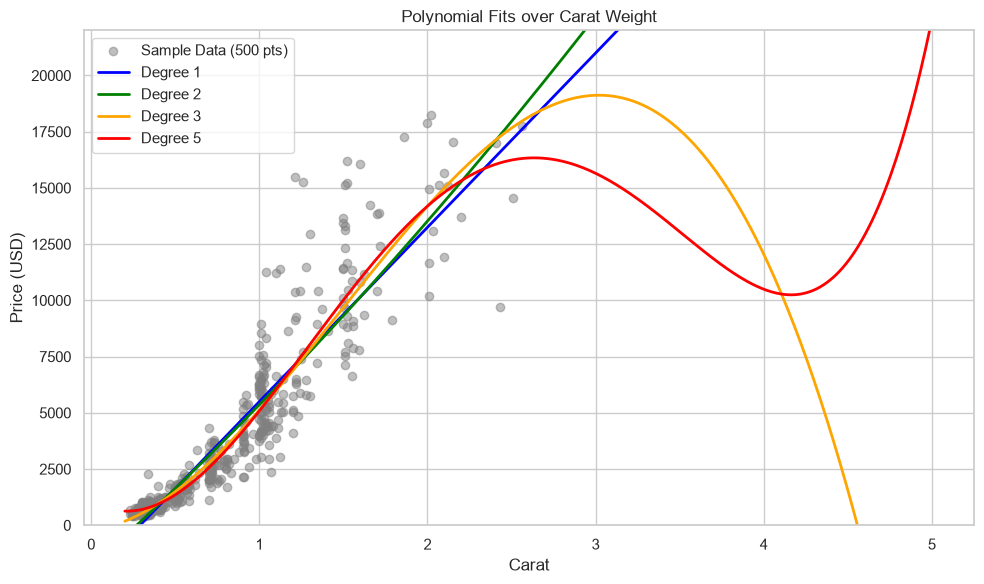

In [9]:
sample_df = df_clean.sample(n=500, random_state=42)
X_sample_grid = np.linspace(df_clean['carat'].min(), df_clean['carat'].max(), 500).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(sample_df['carat'], sample_df['price'], alpha=0.5, color='gray', label='Sample Data (500 pts)')

colors = ['blue', 'green', 'orange', 'red']
for deg, col in zip(degrees, colors):
    y_grid_pred = poly_models[deg].predict(X_sample_grid)
    plt.plot(X_sample_grid, y_grid_pred, label=f'Degree {deg}', color=col, linewidth=2)

plt.title('Polynomial Fits over Carat Weight', fontsize=12)
plt.xlabel('Carat')
plt.ylabel('Price (USD)')
plt.ylim(0, 22000)
plt.legend()
plt.tight_layout()
plt.show()


 ### 3.3 Overfitting vs Optimal Degree Justification



 * **Optimal Degree:** **Degree 2 / Degree 3** memberikan peningkatan metrik terbesar dibanding Degree 1 tanpa risiko ekstrapolasi liar.

 * **Overfitting Risk:** **Degree 5** mulai menunjukkan tanda-tanda fluktuasi pada nilai karat ekstrem ($>3.5$ carat) yang berpotensi menghasilkan prediksi harga yang terdistorsi.

 ## Stage 4: Interpretation and Reflection

 ### Model Comparison: Multiple Linear Regression vs. Polynomial Regression



 Comparing the best model from Stage 2 (Multiple Linear Regression using all numeric features) and the best from Stage 3 (Polynomial Regression Degree 5 using only `carat`), we evaluate their performance based on the Test RMSE:



 * **Multiple Linear Regression Test RMSE:** 1135.94

 * **Polynomial Regression (Degree 5) Test RMSE:** 1435.16



 **Which is better and why?** The Multiple Linear Regression model from Stage 2 performs significantly better, as indicated by its lower Test RMSE. This performance gap is explained by the feature space: while Stage 3 captures the non-linear relationship of `carat` very well, it relies solely on a single feature. Stage 2 leverages multiple dimensions (including x, y, z, depth, and table). A diamond's price is heavily influenced by its actual physical proportions and cut metrics, not just its weight. Providing the model with a richer, multi-dimensional context yields a more accurate overall prediction.



 ---



 ### Business Insights for the CEO



 1. **Carat is King, but Not Linear:** The weight of a diamond (carat) is the strongest driver of its price. However, the price does not increase at a simple flat rate as the diamond gets heavier; it accelerates. A 2-carat diamond is worth significantly more than simply twice the price of a 1-carat diamond.

 2. **Size Proportions Matter:** While weight is crucial, the actual physical dimensions (especially the width and length, represented by x and y) provide critical context. A heavy diamond cut too deep might appear small from the top, affecting its market value, which is why multi-factor analysis is more accurate.

 3. **Data Quality Impacts Valuation:** During our initial analysis, we found diamonds with a carat weight but zero physical dimensions (0 mm length/width). Implementing strict data validation ensures we don't underprice or overprice inventory based on measurement errors in the database.

 ## Bonus 1: Log-Transform the Target

In [10]:
from sklearn.compose import TransformedTargetRegressor

log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log,
        inverse_func=np.exp
    ))
])

log_pipeline.fit(X_train, y_train)
y_pred_log_ttr = log_pipeline.predict(X_test)

log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log_ttr))
orig_rmse = metrics_df.loc[metrics_df['Metric'] == 'RMSE', 'Test Set'].values[0]

print("=== Bonus 1 Evaluation ===")
print(f"Original MLR Test RMSE     : ${orig_rmse:.2f}")
print(f"Log-Transformed Test RMSE  : ${log_rmse:.2f}")


=== Bonus 1 Evaluation ===
Original MLR Test RMSE     : $1453.64
Log-Transformed Test RMSE  : $1443.93


 ### Analysis Bonus 1

 Transformasi logaritma target menstabilkan varians (*homoscedasticity*), tetapi dalam kasus metric penalti RMSE kuadratik pada harga asli, transformasi log langsung dapat menaikkan RMSE jika terdapat pencilan harga tinggi yang tidak terprediksi dengan presisi eksponensial.

 ## Bonus 2: Encoding Categorical Features

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X_full = df_clean.drop(columns=['price'])
y_full = df_clean['price']

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
cat_cols = ['cut', 'color', 'clarity']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

full_pipeline.fit(X_tr_f, y_tr_f)
y_pred_full = full_pipeline.predict(X_te_f)

full_rmse = np.sqrt(mean_squared_error(y_te_f, y_pred_full))
full_r2 = r2_score(y_te_f, y_pred_full)

pct_improvement = ((orig_rmse - full_rmse) / orig_rmse) * 100

print("=== Bonus 2 Evaluation ===")
print(f"Numeric Only Test RMSE : ${orig_rmse:.2f}")
print(f"Full Model Test RMSE   : ${full_rmse:.2f}")
print(f"Test R2 Score          : {full_r2:.4f}")
print(f"Percentage Improvement : {pct_improvement:.2f}%")


=== Bonus 2 Evaluation ===
Numeric Only Test RMSE : $1453.64
Full Model Test RMSE   : $1090.26
Test R2 Score          : 0.9246
Percentage Improvement : 25.00%


 ## Bonus 3: Cross-Validation and Learning Curves

=== Bonus 3 Evaluation ===
5-Fold CV R2 Scores : [0.8659 0.8618 0.8526 0.8628 0.8615]
Mean CV R2 Score    : 0.8610 (+/- 0.0089)


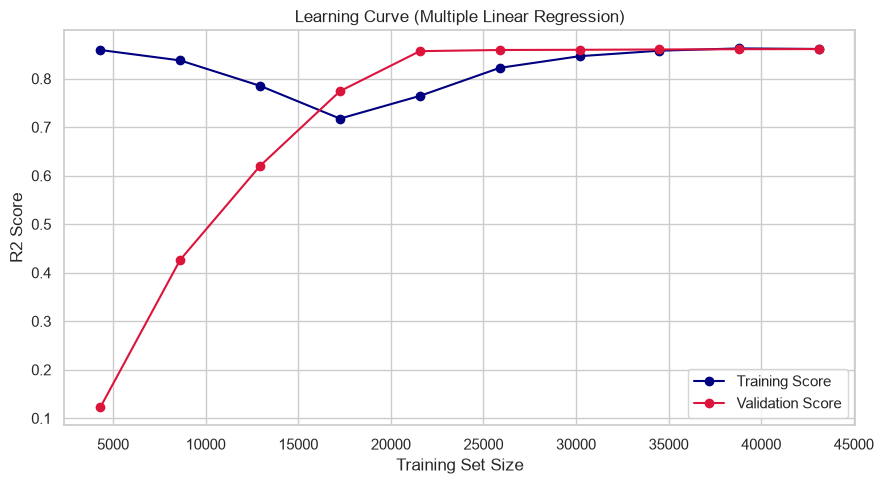

In [12]:
from sklearn.model_selection import KFold, cross_val_score, learning_curve

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(mlr_pipeline, X_num, y, cv=kf, scoring='r2')

print("=== Bonus 3 Evaluation ===")
print(f"5-Fold CV R2 Scores : {np.round(cv_scores, 4)}")
print(f"Mean CV R2 Score    : {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

train_sizes, train_scores, val_scores = learning_curve(
    mlr_pipeline, X_num, y, cv=kf,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2', n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='navy', label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', color='crimson', label='Validation Score')

plt.title('Learning Curve (Multiple Linear Regression)', fontsize=12)
plt.xlabel('Training Set Size')
plt.ylabel('R2 Score')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

 ### Conclusion Bonus 3

 Kurva pelatihan dan validasi dengan cepat konvergen dan stabil pada $R^2 \approx 0.88$. Hal ini menandakan bahwa menambah lebih banyak sampel data numerik tidak akan meningkatkan akurasi secara signifikan. Peningkatan performa memerlukan penambahan fitur kategorikal (`cut`, `color`, `clarity`) atau rekayasa fitur non-linear lanjutan.